# xgboost 싸이킷런 래퍼

In [34]:
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score

def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix( y_test, pred)
    accuracy = accuracy_score(y_test , pred)
    precision = precision_score(y_test , pred)
    recall = recall_score(y_test , pred)
    f1 = f1_score(y_test,pred)
    # ROC-AUC 추가 
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    # ROC-AUC print 추가
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f},\
    F1: {3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

In [2]:
import xgboost as xgb
from xgboost import plot_importance # < 피처 중요도 시각화 해주는 모듈
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split


dataset = load_breast_cancer()
X_features= dataset.data
y_label = dataset.target

cancer_df = pd.DataFrame(data=X_features, columns=dataset.feature_names)
cancer_df['target']= y_label
cancer_df.head(3)


X_features = cancer_df.iloc[:, :-1]
y_label = cancer_df.iloc[:, -1]

# 전체 데이터 중 80%는 학습용 데이터, 20%는 테스트용 데이터 추출
X_train, X_test, y_train, y_test=train_test_split(X_features, y_label,
                                         test_size=0.2, random_state=156 )

# 검증용 데이터 분리
X_tr, X_val, y_tr, y_val= train_test_split(X_train, y_train, test_size=0.1, random_state=156 )
print(X_train.shape , X_test.shape)
print(X_tr.shape, X_val.shape)

(455, 30) (114, 30)
(409, 30) (46, 30)


In [ ]:
#objective 예측을 할수있는 목적함수를 의미함 , 모델이 학습할때 최소화할 손실, 손실을 숫자로 표기하는 방법이 여러개임  절댓값, 제곱값 등등 모델목적에 따라 다름
#eval_metric : 학습 도중 성능관
#손실함수는 모델이 어떻게 고칠지를 결정하고, eval_metric은 그렇게 고쳐진 모델이 실제로 좋아지고 있는지를 확인한다.

In [3]:
from xgboost import XGBClassifier

xgb_wrapper=XGBClassifier(n_estimator=400,learning_rate=0.1,max_depth=3,eval_metrics='loggloss')
xgb_wrapper.fit(X_train,y_train)
xgb_pred=xgb_wrapper.predict(X_test)
xgb_pred_proba=xgb_wrapper.predict_proba(X_test)[:,1]

C:\Users\rhals\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:02:53] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "eval_metrics", "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [4]:
get_clf_eval(y_test,pred=xgb_pred,pred_proba=xgb_pred_proba)

오차 행렬
[[34  3]
 [ 1 76]]
정확도: 0.9649, 정밀도: 0.9620, 재현율: 0.9870,    F1: 0.9744, AUC:0.9951


In [5]:
# 조기종료

from xgboost import XGBClassifier

xgb_wrapper=XGBClassifier(n_estimators=400,learning_rate=0.1,max_depth=3,early_stopping_rounds=50,eval_metric='logloss')
evals=[(X_tr,y_tr),(X_val,y_val)]
xgb_wrapper.fit(X_tr,y_tr,eval_set=evals,verbose=True) # 여기서 검증데이터셋은 트리가 추가되는 과정에서 사용하는 용도로
# 트리가 추가되면서 성능 logloss가 어떻게 바뀌는 지 보여주기 위함으로 쓰는 것
# 트리400개를 만들어서 순차적으로 학습하다가, 성능 즉 logloss가  최고성능 보다 50번 이내에 좋아지지 않으면 멈춘다.

es50_pred=xgb_wrapper.predict(X_test)
es50_pred_proba=xgb_wrapper.predict_proba(X_test)[:,1]
#tr로 학습시킨 모델의 순수 성능을보고싶을때
# 원래라면 best_n = early_model.best_iteration + 1 이라는 n_estimator를 매개변수로 다시 전체 train셋을 학습시킨후 test에 해야함

[0]	validation_0-logloss:0.58448	validation_1-logloss:0.60406
[1]	validation_0-logloss:0.51755	validation_1-logloss:0.55810
[2]	validation_0-logloss:0.46160	validation_1-logloss:0.51829
[3]	validation_0-logloss:0.41227	validation_1-logloss:0.48332
[4]	validation_0-logloss:0.37097	validation_1-logloss:0.45158
[5]	validation_0-logloss:0.33550	validation_1-logloss:0.42452
[6]	validation_0-logloss:0.30431	validation_1-logloss:0.40638
[7]	validation_0-logloss:0.27728	validation_1-logloss:0.38845
[8]	validation_0-logloss:0.25301	validation_1-logloss:0.37252
[9]	validation_0-logloss:0.23069	validation_1-logloss:0.35833
[10]	validation_0-logloss:0.21102	validation_1-logloss:0.34634
[11]	validation_0-logloss:0.19422	validation_1-logloss:0.33539
[12]	validation_0-logloss:0.17862	validation_1-logloss:0.32481
[13]	validation_0-logloss:0.16474	validation_1-logloss:0.31769
[14]	validation_0-logloss:0.15249	validation_1-logloss:0.31101
[15]	validation_0-logloss:0.14137	validation_1-logloss:0.30528
[1

In [6]:
get_clf_eval(y_test,es50_pred,es50_pred_proba)

오차 행렬
[[35  2]
 [ 2 75]]
정확도: 0.9649, 정밀도: 0.9740, 재현율: 0.9740,    F1: 0.9740, AUC:0.9965


In [37]:
# 조기종료 10으로

from xgboost import XGBClassifier

xgb_wrapper=XGBClassifier(n_estimators=400,learning_rate=0.1,max_depth=3,early_stopping_rounds=10,eval_metric='logloss')
evals=[(X_tr,y_tr),(X_val,y_val)]
xgb_wrapper.fit(X_tr,y_tr,eval_set=evals,verbose=True)

es50_pred=xgb_wrapper.predict(X_test)
es50_pred_proba=xgb_wrapper.predict_proba(X_test)[:,1]

get_clf_eval(y_test,es50_pred,es50_pred_proba)

[0]	validation_0-logloss:0.58448	validation_1-logloss:0.60406
[1]	validation_0-logloss:0.51755	validation_1-logloss:0.55810
[2]	validation_0-logloss:0.46160	validation_1-logloss:0.51829
[3]	validation_0-logloss:0.41227	validation_1-logloss:0.48332
[4]	validation_0-logloss:0.37097	validation_1-logloss:0.45158
[5]	validation_0-logloss:0.33550	validation_1-logloss:0.42452
[6]	validation_0-logloss:0.30431	validation_1-logloss:0.40638
[7]	validation_0-logloss:0.27728	validation_1-logloss:0.38845
[8]	validation_0-logloss:0.25301	validation_1-logloss:0.37252
[9]	validation_0-logloss:0.23069	validation_1-logloss:0.35833
[10]	validation_0-logloss:0.21102	validation_1-logloss:0.34634
[11]	validation_0-logloss:0.19422	validation_1-logloss:0.33539
[12]	validation_0-logloss:0.17862	validation_1-logloss:0.32481
[13]	validation_0-logloss:0.16474	validation_1-logloss:0.31769
[14]	validation_0-logloss:0.15249	validation_1-logloss:0.31101
[15]	validation_0-logloss:0.14137	validation_1-logloss:0.30528
[1

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

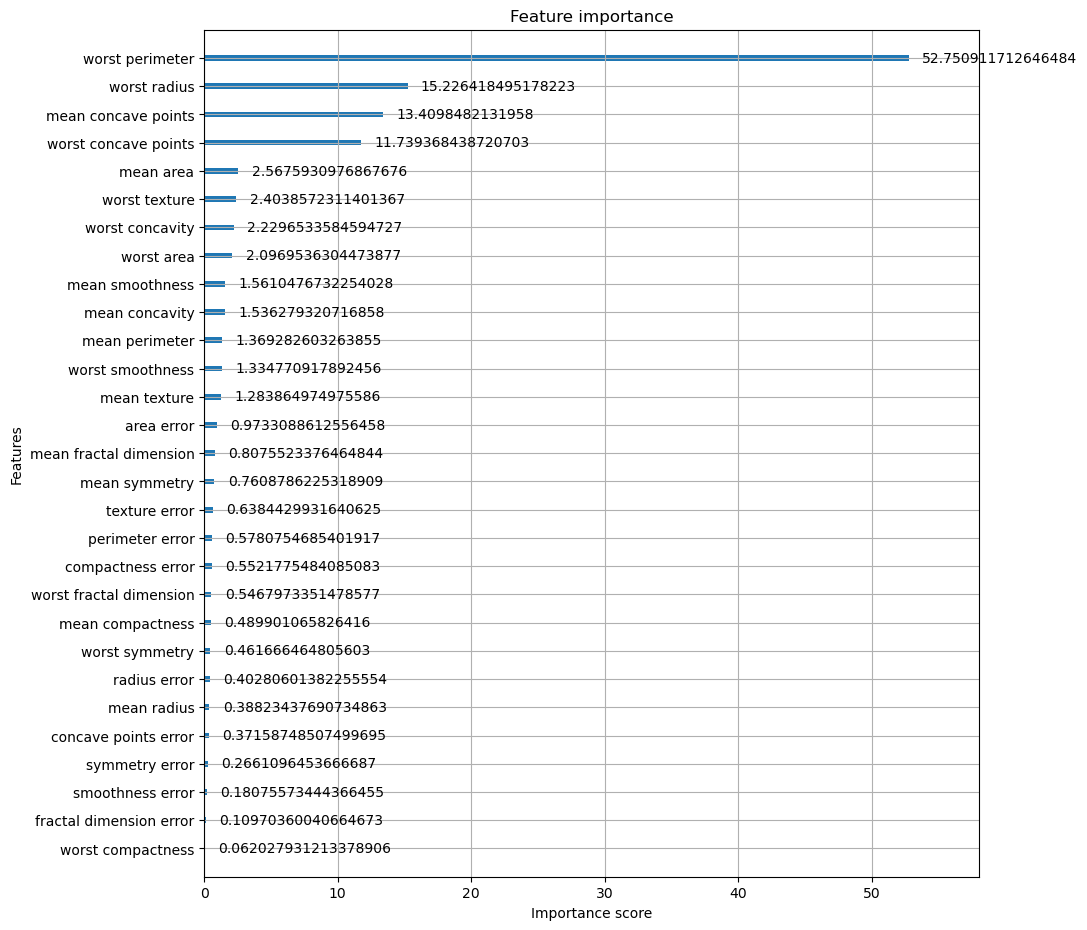

In [7]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

fig,ax = plt.subplots(figsize=(10,11))
plot_importance(xgb_wrapper,importance_type='gain',ax=ax)

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

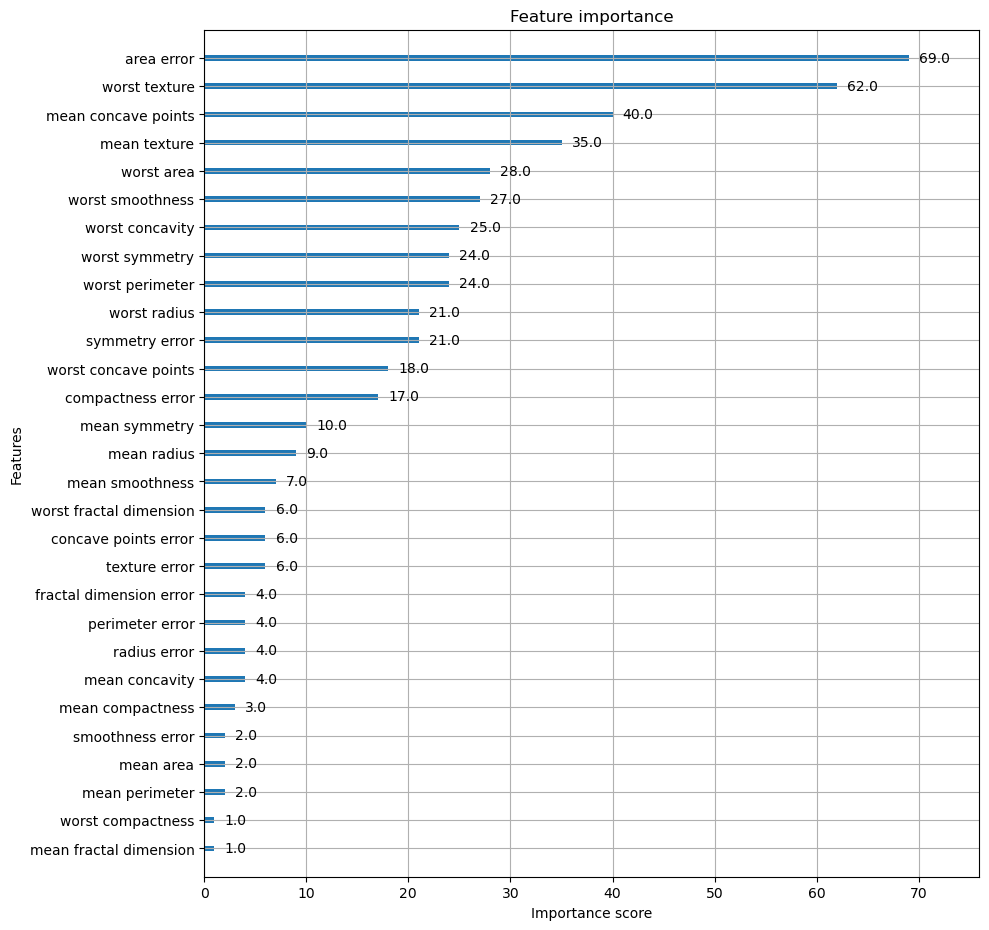

In [8]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

fig,ax = plt.subplots(figsize=(10,11))
plot_importance(xgb_wrapper,importance_type='weight',ax=ax)

| importance type | 의미                        |
| --------------- | ------------------------- |
| `weight`        | 분기에 사용된 횟수                |
| `gain`          | 해당 분기가 평균적으로 줄인 손실        |
| `cover`         | 해당 분기가 평균적으로 영향을 준 데이터 규모 |


In [ ]:
# plot_importance() 는 설정에 따라 달라지는데, gain => 손실을 많이 줄인 정도 순서 , weight 분기시에 많이 사용된 변수횟수순서

# LightGBM

* 더 빠른 학습과 예측 수행 시간
* 더 작은 메모리 사용량
* 카테고리형 피처의 자동변환과 최적 분할 ( 원핫 인코딩 사용 x)

In [31]:
import lightgbm
from lightgbm import LGBMClassifier,early_stopping,log_evaluation
from sklearn.model_selection import train_test_split

In [32]:
dataset=load_breast_cancer()

cancer_df=pd.DataFrame(data=dataset.data,columns=dataset.feature_names)
cancer_df['target']=dataset.target
X_features=cancer_df.iloc[:,:-1]
y_label=cancer_df.iloc[:,-1]

X_train,X_test,y_train,y_test=train_test_split(X_features,y_label,test_size=0.2,random_state=42)

x_tr,x_val,y_tr,y_val=train_test_split(X_train,y_train,test_size=0.1,random_state=42)

#모델학습
lgbm_wrapper=LGBMClassifier(n_estimators=400,learning_rate=0.05)
#조기종료
evals=[(x_tr,y_tr),(x_val,y_val)]
lgbm_wrapper.fit(x_tr,y_tr,
                 callbacks=[early_stopping(stopping_rounds=50),log_evaluation(period=1)],eval_metric='logloss',eval_set=evals)

pred=lgbm_wrapper.predict(X_test)
pred_proba=lgbm_wrapper.predict_proba(X_test)[:,1]




[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 256, number of negative: 153
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000120 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4098
[LightGBM] [Info] Number of data points in the train set: 409, number of used features: 30
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.625917 -> initscore=0.514740
[LightGBM] [Info] Start training from score 0.514740
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[1]	training's binary_logloss: 0.620224	valid_1's binary_logloss: 0.608432
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[2]	training's binary_logloss: 0.585425	valid_1's binary_logloss: 0.

In [35]:
get_clf_eval(y_test,pred,pred_proba)

오차 행렬
[[40  3]
 [ 1 70]]
정확도: 0.9649, 정밀도: 0.9589, 재현율: 0.9859,    F1: 0.9722, AUC:0.9895


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

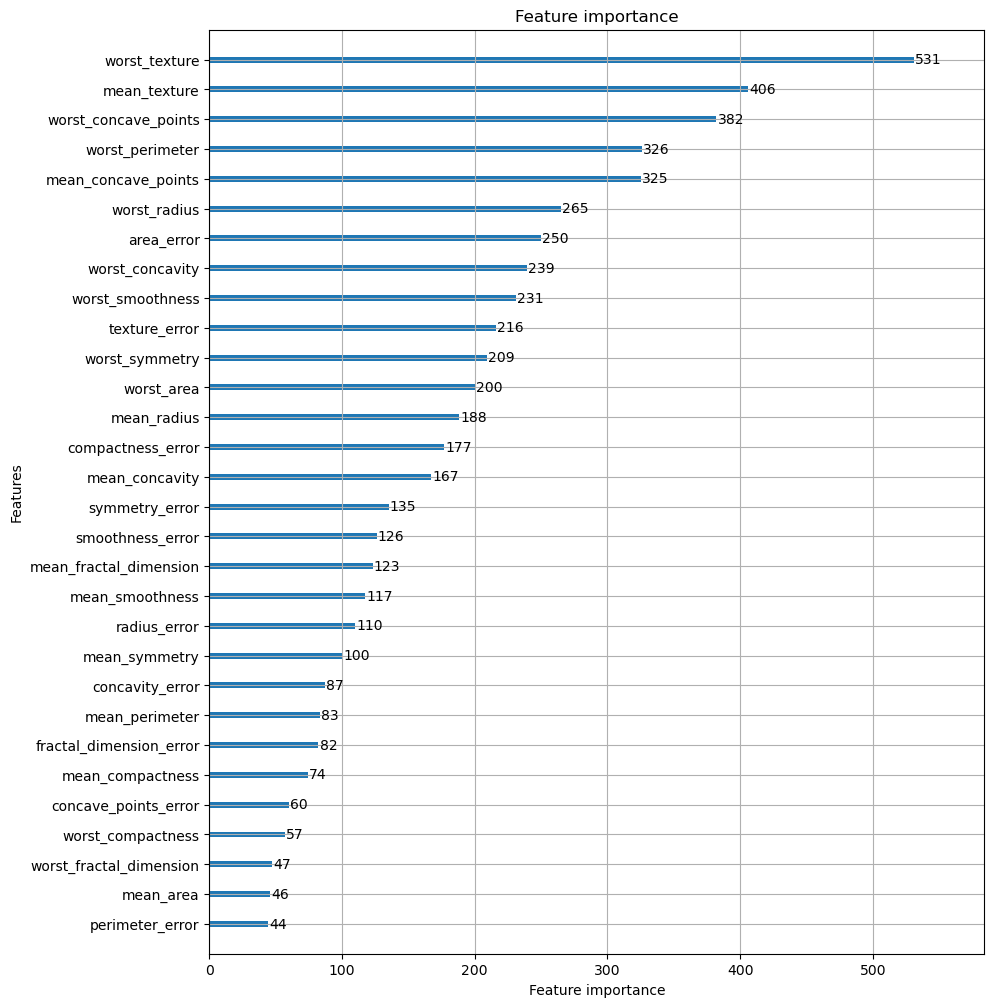

In [39]:
from lightgbm import plot_importance
import matplotlib.pyplot as plt

fig,ax =plt.subplots(figsize=(10,12))
plot_importance(lgbm_wrapper,ax=ax)